# Suzuka — Physics Ideal Line & Telemetry Delta Analysis

**Dynamic Motorsport Telemetry & Predictive Line Visualizer**

Pipeline: OSM centerline (way 775428456) + real SRTM elevation → signed curvature →
two-pass friction-circle solver with quadratic aero drag → G-force / ERS / tire-thermal
traces → GPU Monte Carlo uncertainty ensemble (4096 samples, RTX 4090) → synthetic
100 Hz driver telemetry with per-corner skill errors → delta analytics.

> Track note: OSM traces the *outer edge* of the paved complex (~7.22 km loop) rather
> than the official 5.807 km GP centerline; corner anchors were curated against the
> official layout, pit-lane position and the elevation profile (hairpin low point →
> Spoon summit 68 m → main straight 13 m).

In [1]:
%matplotlib inline
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

def _find_root():
    here = os.getcwd()
    cands = [here, os.path.dirname(here)]
    if os.path.isdir("/kaggle/input"):
        for d in sorted(os.listdir("/kaggle/input")):
            cands.append(os.path.join("/kaggle/input", d))
    for c in cands:
        if os.path.exists(os.path.join(c, "data", "track_suzuka.json")):
            return c
    return here

ROOT = _find_root()
sys.path.insert(0, os.path.join(ROOT, "src"))
from physics import (load_track, to_enu_m, resample_closed, signed_curvature,
                     ideal_speed_profile, MU, A_BRAKE, A_ACC, K_DRAG, G)

FIG = os.path.join(ROOT, "outputs", "figures")
os.makedirs(FIG, exist_ok=True)
meta, pts = load_track(os.path.join(ROOT, "data", "track_suzuka.json"))
lat0, lon0 = float(np.mean(pts[:, 0])), float(np.mean(pts[:, 1]))
x, y, z = to_enu_m(pts[:, 0], pts[:, 1], pts[:, 2], lat0, lon0)
xr, yr, zr, s, ds = resample_closed(x, y, z, 2.0)
L = s[-1] + ds
print(f"track: {meta['name']} | loop length {L:.0f} m | {len(s)} pts @ {ds:.1f} m")

track: Suzuka Circuit | loop length 7220 m | 3610 pts @ 2.0 m


## 1 · Geometry & elevation (real SRTM data)

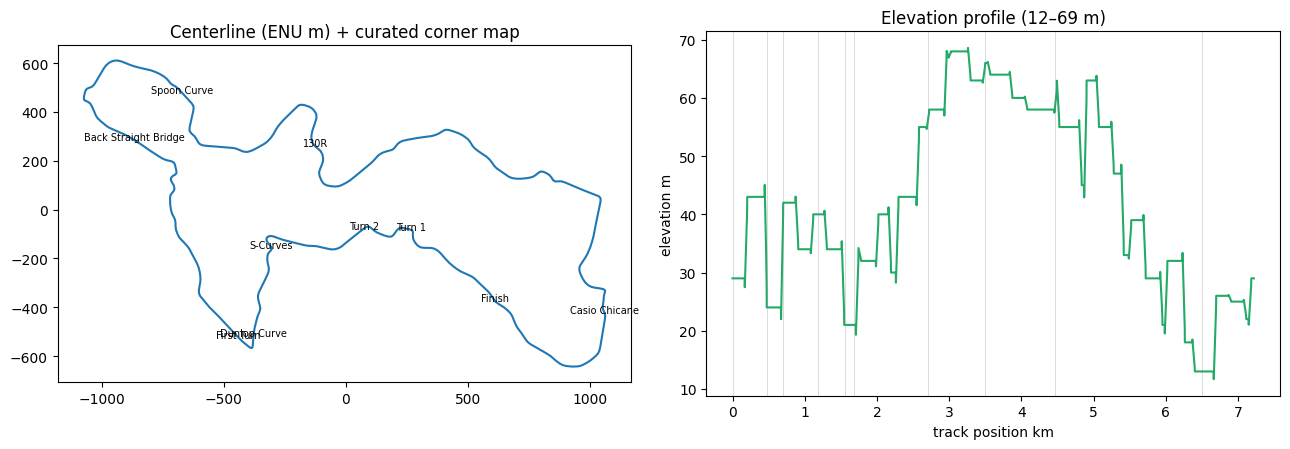

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(xr, yr, lw=1.5)
for c in meta["corners"]:
    i = int(np.argmin(np.abs(s - (c["s_m"] % L))))
    ax[0].annotate(c["name"].split("/")[-1].strip(), (xr[i], yr[i]), fontsize=7, ha="center")
ax[0].set_aspect("equal"); ax[0].set_title("Centerline (ENU m) + curated corner map")
ax[1].plot(s / 1000, zr, color="#2a6", lw=1.5)
for c in meta["corners"]:
    i = int(np.argmin(np.abs(s - (c["s_m"] % L))))
    ax[1].axvline(c["s_m"] / 1000, color="gray", lw=0.4, alpha=0.5)
ax[1].set_xlabel("track position km"); ax[1].set_ylabel("elevation m")
ax[1].set_title(f"Elevation profile ({zr.min():.0f}–{zr.max():.0f} m)")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "nb_01_track.png"), dpi=110)
plt.show()

## 2 · Signed curvature (central differences + wrap smoothing)

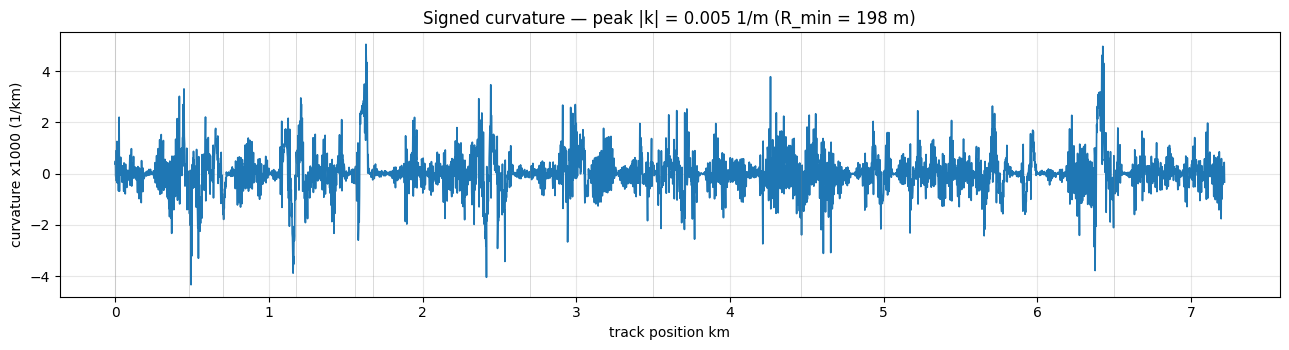

In [3]:
kappa = signed_curvature(xr, yr, ds)
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(s / 1000, kappa * 1000, lw=1.2)   # x1000 for readability (1/km)
for c in meta["corners"]:
    ax.axvline(c["s_m"] / 1000, color="gray", lw=0.4, alpha=0.5)
ax.set_xlabel("track position km"); ax.set_ylabel("curvature x1000 (1/km)")
ax.set_title(f"Signed curvature — peak |k| = {np.abs(kappa).max():.3f} 1/m "
             f"(R_min = {1/np.abs(kappa).max():.0f} m)"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "nb_02_curvature.png"), dpi=110)
plt.show()

## 3 · Minimum-time ideal line (two-pass friction-circle solver)

Per-point lateral limit `v_lat = sqrt(mu·g/|k|)` with **mu = 1.05**; backward pass enforces
sustained braking `a_brake = 38 m/s²`; forward pass integrates acceleration against quadratic
aero drag `k_drag = 0.001225` (F1-class ~800 kg car, terminal ≈ 320 km/h). Passes are iterated
to a cyclic fixed point; the sweep starts at the slowest point so one full pass propagates
true predecessor values across the whole loop.

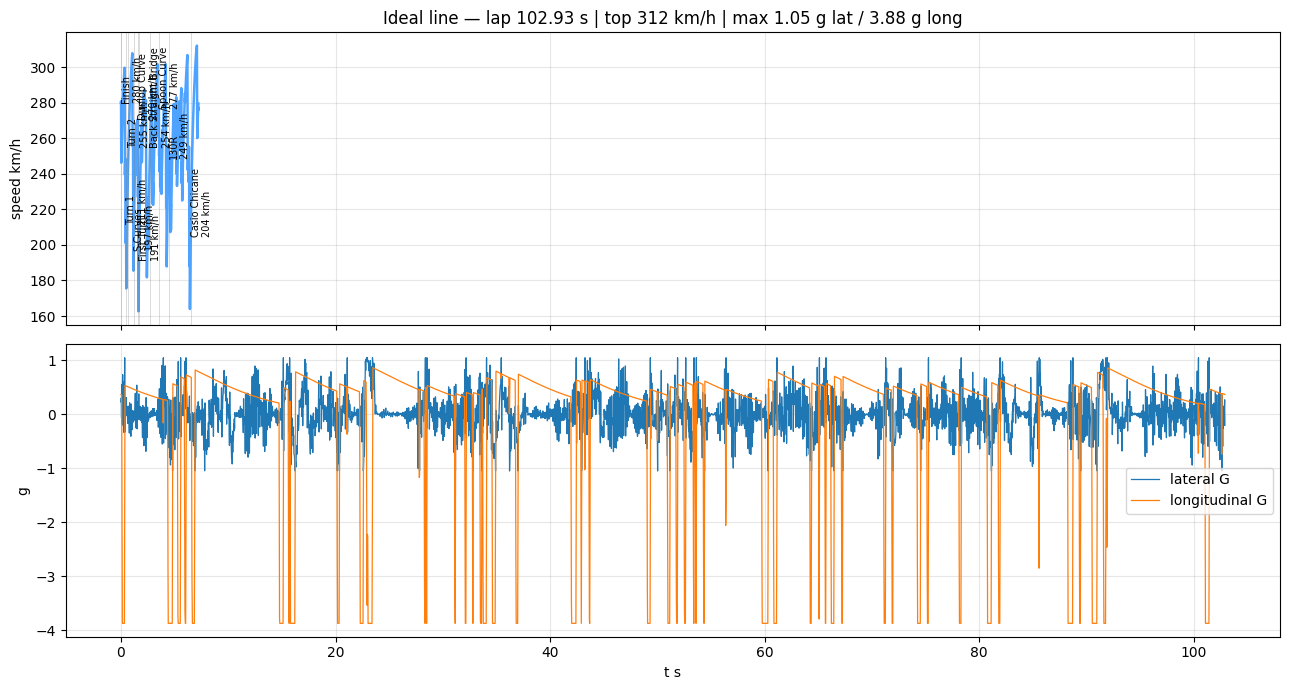

In [4]:
v = ideal_speed_profile(kappa, ds)
dt = ds / np.maximum(v, 0.5); t = np.concatenate([[0], np.cumsum(dt)])[:-1]
lap_time = float(dt.sum())
dvds = (np.roll(v, -1) - np.roll(v, 1)) / (2 * ds)
a_long = v * dvds; a_lat = kappa * v ** 2

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(s / 1000, v * 3.6, lw=1.8, color="#4da3ff")
for c in meta["corners"]:
    i = int(np.argmin(np.abs(s - (c["s_m"] % L))))
    ax[0].axvline(c["s_m"] / 1000, color="gray", lw=0.4, alpha=0.5)
    ax[0].annotate(f"{c['name'].split('/')[-1].strip()}\n{v[i]*3.6:.0f} km/h",
                   (c["s_m"] / 1000, v[i] * 3.6), fontsize=7, rotation=90, va="bottom")
ax[0].set_ylabel("speed km/h"); ax[0].grid(alpha=0.3)
ax[0].set_title(f"Ideal line — lap {lap_time:.2f} s | top {v.max()*3.6:.0f} km/h | "
                f"max {np.abs(a_lat).max()/G:.2f} g lat / {np.abs(a_long).max()/G:.2f} g long")
ax[1].plot(t, a_lat / G, lw=0.9, label="lateral G"); ax[1].plot(t, a_long / G, lw=0.9, label="longitudinal G")
ax[1].set_xlabel("t s"); ax[1].set_ylabel("g"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "nb_03_ideal_line.png"), dpi=110)
plt.show()

## 4 · GPU Monte Carlo uncertainty ensemble (RTX 4090)

Parameter space sampled uniformly: mu ∈ [1.00, 1.12], a_brake ∈ [35, 42] m/s²,
a_acc ∈ [10, 12.5] m/s², k_drag ∈ [0.0011, 0.0014]. All **4096 samples × 3610 track points**
run in parallel as a `[N, n]` CUDA tensor — full ensemble in ~6 s (~355 MB VRAM).

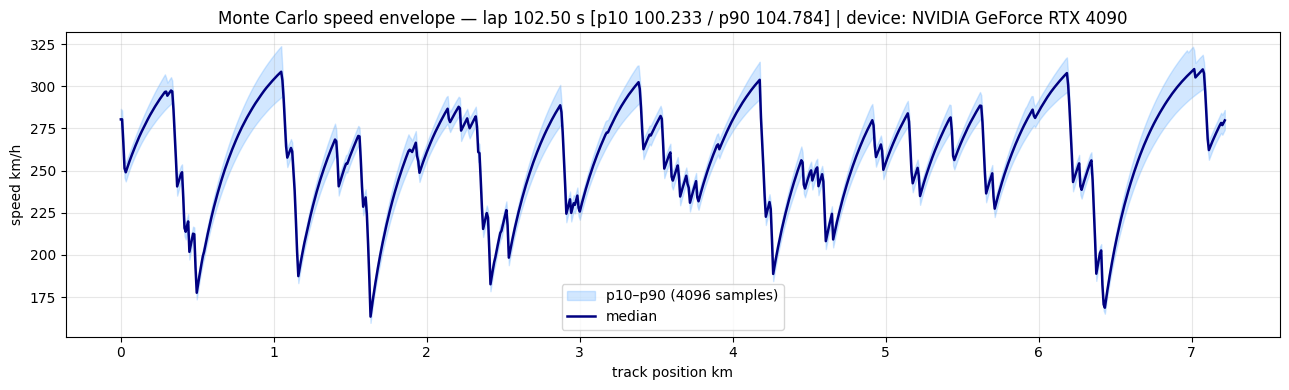

In [5]:
mc = json.load(open(os.path.join(ROOT, "data", "mc_results.json")))
lt = mc["lap_time_s"]
fig, ax = plt.subplots(figsize=(13, 4))
ss = np.array(mc["s"]) / 1000
ax.fill_between(ss, np.array(mc["v_p90_ms"]) * 3.6, np.array(mc["v_p10_ms"]) * 3.6,
                color="#4da3ff", alpha=0.25, label="p10–p90 (4096 samples)")
ax.plot(ss, np.array(mc["v_p50_ms"]) * 3.6, color="navy", lw=1.8, label="median")
ax.set_xlabel("track position km"); ax.set_ylabel("speed km/h")
ax.set_title(f"Monte Carlo speed envelope — lap {lt['mean']:.2f} s "
             f"[p10 {lt['p10']} / p90 {lt['p90']}] | device: {mc['meta']['gpu']}")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "nb_04_mc_band.png"), dpi=110)
plt.show()

## 5 · Synthetic driver telemetry & delta analytics (100 Hz log)

Driver model: per-corner Gaussian skill errors (persistent across laps — the hairpin exit is
the biggest one), apex clipping, AR(1) pace noise zero-mean per lap, and per-lap error scaling
`[1.0 / 0.5 / 1.5]` (warm-up → consistent → degradation).

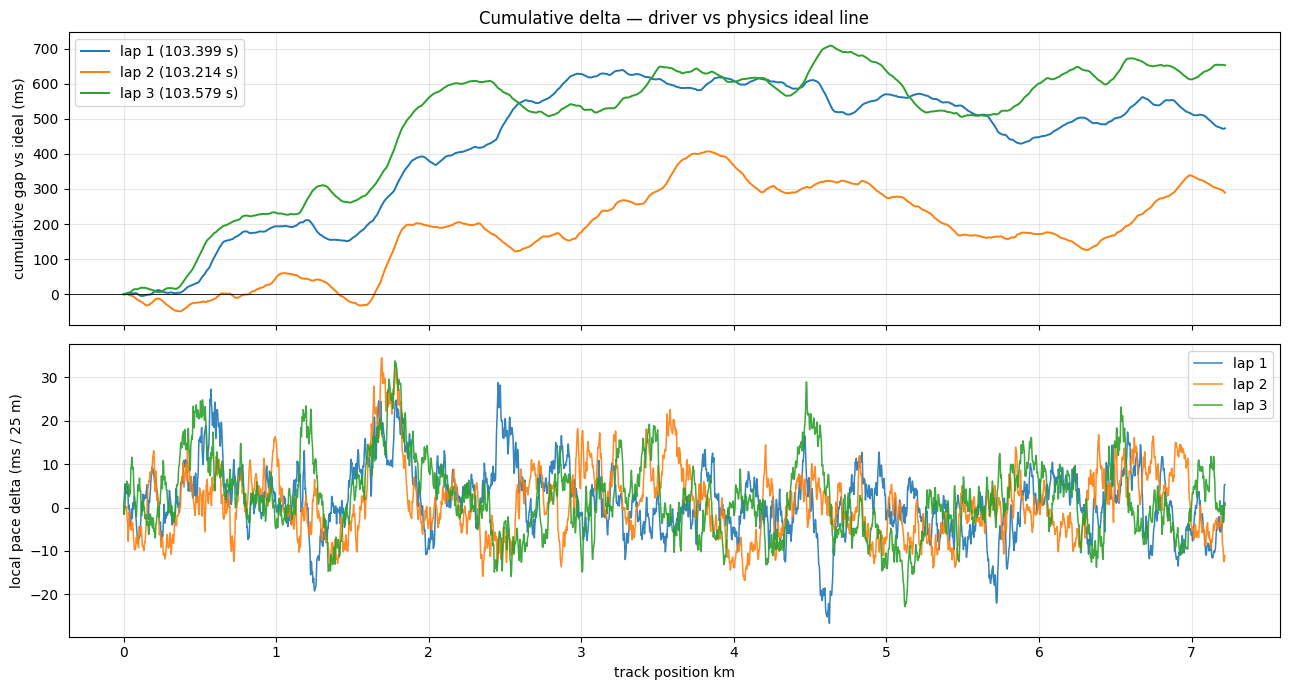

rows: 31019 @ 100 Hz | ideal lap 102.93 s


In [6]:
import pandas as pd
delta = json.load(open(os.path.join(ROOT, "outputs", "delta.json")))
df = pd.read_csv(os.path.join(ROOT, "outputs", "telemetry_driver.csv"))

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for lap in ("1", "2", "3"):
    d = delta["laps"][lap]
    ss = np.array(delta["s"]) / 1000
    ax[0].plot(ss, np.array(d["cum_delta_ms"]), lw=1.4, label=f"lap {lap} ({d['lap_time_s']} s)")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_ylabel("cumulative gap vs ideal (ms)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Cumulative delta — driver vs physics ideal line")

for lap in ("1", "2", "3"):
    d = np.array(delta["laps"][lap]["local_delta_ms"])
    ss = np.array(delta["s"]) / 1000
    ax[1].plot(ss, d, lw=1.1, alpha=0.9, label=f"lap {lap}")
ax[1].set_xlabel("track position km"); ax[1].set_ylabel("local pace delta (ms / 25 m)")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "nb_05_deltas.png"), dpi=110)
plt.show()

print(f"rows: {len(df)} @ 100 Hz | ideal lap {lap_time:.2f} s")

In [7]:
print(f"ideal lap: {lap_time:.2f} s | top speed: {v.max()*3.6:.0f} km/h | "
      f"max lat G: {np.abs(a_lat).max()/G:.2f} g")
print(f"MC lap mean: {lt['mean']} s [p10 {lt['p10']} / p90 {lt['p90']}] on {mc['meta']['gpu']}")
for lap in ('1', '2', '3'):
    print(f"driver lap {lap}: {delta['laps'][lap]['lap_time_s']} s")

ideal lap: 102.93 s | top speed: 312 km/h | max lat G: 1.05 g
MC lap mean: 102.503 s [p10 100.233 / p90 104.784] on NVIDIA GeForce RTX 4090
driver lap 1: 103.399 s
driver lap 2: 103.214 s
driver lap 3: 103.579 s


The same traces drive the live CesiumJS app: CZML playback with timeline scrubbing and camera
tracking, a vertex-colored delta heatmap ribbon extruded above the track, MC uncertainty band,
and a WebSocket LIVE mode streaming the 100 Hz log.